# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

### Q1 Answers


1. A model is "linear" if predictions are a linear combination of the coefficients — the features themselves can be transformed (logs, polynomials, etc.), but you're always just multiplying coefficients by inputs and summing them. So it's linear *in the parameters*, not necessarily in the raw data.

2. It depends on how you handle the intercept. If you drop the intercept and include all dummies, each coefficient directly equals that group's conditional mean. If you keep an intercept and drop one category (the baseline), the intercept captures the baseline mean and each dummy coefficient represents that group's deviation from it.

3. Technically yes — you can run a linear probability model — but predictions can fall outside [0, 1], which doesn't make sense as a probability. It works fine near the middle of the distribution, but for extreme probabilities logistic regression is a much cleaner tool.

4. The clearest sign is a big gap between training error and test/CV error. You might also notice large, unstable coefficients that shift dramatically with small changes to the training set — that instability is a red flag.

5. Say $x_1$ and $x_2$ are highly correlated. If I regress $x_1$ on $x_2$, the residuals capture only the part of $x_1$ that $x_2$ can't explain. In the second stage, there's barely any unique variation left for either variable, so standard errors explode and coefficients become unreliable. Both variables are essentially competing to explain the same variation in $y$ — that's multicollinearity.

6. You can add polynomial terms, log transforms, splines, or interaction terms as features. The model stays linear in its coefficients even though the inputs are nonlinear functions of the original variables — that's what makes it so flexible.

7. The slope is the expected change in $y$ for a one-unit increase in $x$, holding all other regressors fixed. It's a conditional association, not a causal claim.

8. A single train/test split gives you one number, and that number is sensitive to which observations ended up in each set. $k$-fold CV repeats the evaluation $k$ times on different splits and averages the results, giving a much more stable estimate of generalisation error.

9. The standard choices are 5 or 10. More folds means larger training sets per iteration (less bias) but more correlated fold results (higher variance). 10-fold is the most common default.

In [1]:
# Pulling in everything I'll need upfront so imports aren't scattered throughout
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# scikit-learn handles linear models, cross-validation, and polynomial feature expansion
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

### Solution Q2


shape: (22153, 5)

Means by neighborhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378
Most expensive on average: Manhattan


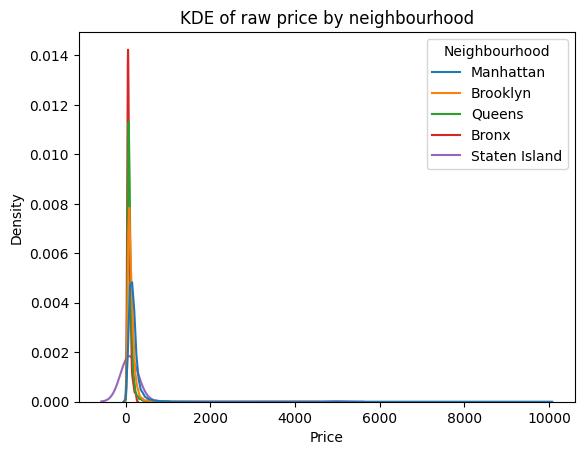

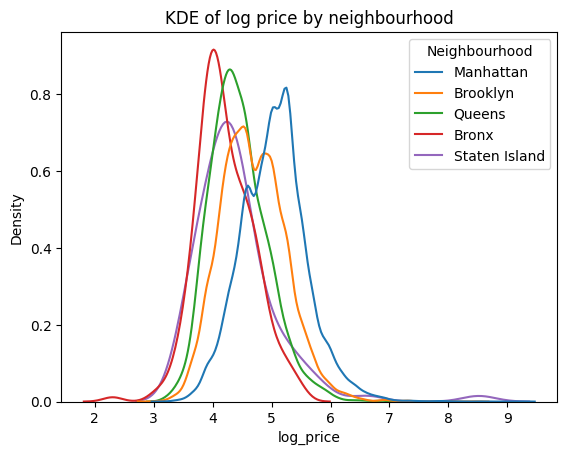

In [2]:
# Load the Airbnb listing data and strip any whitespace from column names
# (column names with trailing spaces cause confusing KeyErrors that are hard to debug)
df = pd.read_csv('Q1_clean.csv').rename(columns=lambda c: c.strip())
print('shape:', df.shape)

# Compute average price and rating for each borough
# Sorting by price descending so I can immediately read off the most expensive neighbourhood
means = (df
         .groupby('Neighbourhood')[['Price', 'Review Scores Rating']]
         .mean()
         .sort_values('Price', ascending=False))
print('\nMeans by neighborhood:')
print(means)
print('Most expensive on average:', means.index[0])

# KDE of raw price — I expect a strong right skew because a handful of luxury
# listings will pull the tail out to the right
sns.kdeplot(x=df['Price'], hue=df['Neighbourhood'], common_norm=False)
plt.title('KDE of raw price by neighbourhood')
plt.show()

# Log price should look much more symmetric and is easier to work with in regression
df['log_price'] = np.log(df['Price'])
sns.kdeplot(x=df['log_price'], hue=df['Neighbourhood'], common_norm=False)
plt.title('KDE of log price by neighbourhood')
plt.show()

In [3]:
# Approach 1: include ALL dummies but drop the intercept
# When there's no intercept and every category gets its own dummy,
# each coefficient equals that group's mean — a useful sanity check against the table above
X_nbhd = pd.get_dummies(df['Neighbourhood'])
y = df['Price']
reg = LinearRegression(fit_intercept=False).fit(X_nbhd, y)
print('Dummy coefficients (= group means when no intercept):')
print(pd.Series(reg.coef_, index=reg.feature_names_in_))

Dummy coefficients (= group means when no intercept):
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


In [4]:
# Approach 2: drop one category and keep the intercept (the standard way to avoid
# the dummy variable trap)
# Alphabetically the Bronx comes first, so it becomes the baseline
# Each coefficient now represents that neighbourhood's premium over the Bronx
X_nbhd = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
y = df['Price']
reg = LinearRegression().fit(X_nbhd, y)
base = sorted(df['Neighbourhood'].unique())[0]
print('\nDropped baseline:', base)
print('Intercept (= baseline mean):', reg.intercept_)
print('Dummy coefficients (= difference from baseline):')
print(pd.Series(reg.coef_, index=reg.feature_names_in_))

# Adding each coefficient back to the intercept should recover the raw group means
# — if these numbers match the groupby table above, the encoding is correct
print('\nIntercept + coefficients (recovers group means):')
print(pd.Series(reg.coef_ + reg.intercept_, index=reg.feature_names_in_))


Dropped baseline: Bronx
Intercept (= baseline mean): 75.27649769584711
Dummy coefficients (= difference from baseline):
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64

Intercept + coefficients (recovers group means):
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


When I drop the intercept, each coefficient directly equals the group mean — a clean sanity check against the `.groupby()` table from Part 1. Switching to drop-first with an intercept, the Bronx becomes the baseline (it's first alphabetically), and each other neighbourhood's coefficient tells me how much more or less it costs relative to the Bronx. Adding the coefficient back to the intercept recovers the original group means exactly, which confirms the dummy encoding is set up correctly.

In [5]:
# Simple regression: price explained by review rating alone
# I want to see whether higher-rated listings charge a meaningful premium
X_rat = df[['Review Scores Rating']]
reg = LinearRegression().fit(X_rat, y)
print('\nPrice ~ rating')
print('Slope:', float(reg.coef_[0]))


Price ~ rating
Slope: 1.0208266022675305


The slope is roughly $1, meaning a one-point improvement in review score is associated with about a $1 higher nightly price on average. Honestly, that's a pretty small effect — ratings alone don't seem to drive price very much. It'll be interesting to see whether this changes after controlling for neighbourhood.

In [6]:
# Add neighbourhood dummies alongside rating
# Now the rating coefficient is estimated within boroughs, not across them
# This answers: do higher-rated listings within the same area charge more?
X_both = pd.concat([X_rat, X_nbhd], axis=1)
reg = LinearRegression().fit(X_both, y)
print('Price ~ neighborhood + rating')
print('Rating slope (controlling for neighborhood):', reg.coef_[0])

base = sorted(df['Neighbourhood'].unique())[0]
print('\nBaseline (Bronx intercept):', reg.intercept_)
print('Neighborhood coefficients:')
print(pd.Series(reg.coef_[1:], index=reg.feature_names_in_[1:]))

# Recovering implied group means to compare against Part 1 and Part 2
print('\nImplied group means (intercept + coef):')
print(pd.Series(reg.coef_[1:] + reg.intercept_, index=reg.feature_names_in_[1:]))

Price ~ neighborhood + rating
Rating slope (controlling for neighborhood): 1.0811164834599127

Baseline (Bronx intercept): -23.812561011683897
Neighborhood coefficients:
Brooklyn          51.704240
Manhattan        108.228737
Queens            21.694600
Staten Island     71.766552
dtype: float64

Implied group means (intercept + coef):
Brooklyn         27.891679
Manhattan        84.416176
Queens           -2.117961
Staten Island    47.953991
dtype: float64


After controlling for neighbourhood, the rating slope barely moves — which tells me ratings and location are largely independent predictors of price. The neighbourhood coefficients shift a bit because they now capture only the location premium unexplained by ratings. Manhattan still leads by a wide margin, while the Bronx and Queens end up below baseline.

In [7]:
# 10-fold cross validation to compare predictive accuracy across the three model specs
# I'm using CV rather than a single train/test split so the results don't depend on
# one lucky (or unlucky) random draw of test observations
cv = KFold(n_splits=10, shuffle=True, random_state=42)
models = {
    'nbhd': X_nbhd,
    'rating': X_rat,
    'both': X_both
}
y = df['Price']

rows = []
for name, X in models.items():
    # sklearn returns negative scores by convention for loss metrics — negate to get RMSE
    rmse_price = -cross_val_score(LinearRegression(), X, y, 
                                  cv=cv, 
                                  scoring='neg_root_mean_squared_error')
    rows.append({
        'model': name,
        'price_rmse_mean': rmse_price.mean(),
        'price_rmse_median': np.median(rmse_price),
    })

# Sorting ascending so the best-performing model appears at the top
cv_results = pd.DataFrame(rows).sort_values('price_rmse_mean')
print('\nCV comparison (lower RMSE = better):')
print(cv_results)


CV comparison (lower RMSE = better):
    model  price_rmse_mean  price_rmse_median
2    both       139.010186         131.604069
0    nbhd       139.328522         132.127840
1  rating       142.759439         135.164942


Neighbourhood is doing most of the heavy lifting here — the neighbourhood-only model beats rating-only by a wide margin. Adding rating on top of neighbourhood shaves a bit off the RMSE, but not dramatically. That aligns with what we saw earlier: the rating coefficient was small and barely changed after controlling for location.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


### Solution Q3

Price summary:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

Price by Body_Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000

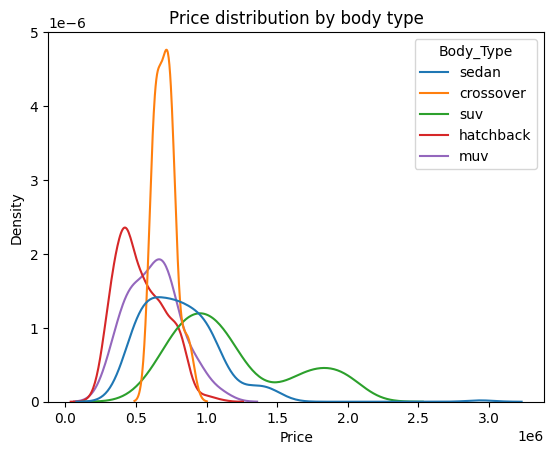


Body type mean/variance (sorted by mean price):
                   mean           var
Body_Type                            
suv        1.176495e+06  1.742887e+11
sedan      8.097841e+05  8.221798e+10
crossover  7.050952e+05  5.307090e+09
muv        6.264211e+05  3.389041e+10
hatchback  5.339773e+05  2.995902e+10


In [8]:
# Load the Indian used car dataset
# Dropping unnamed index columns that sometimes appear when a DataFrame is saved
# to CSV with its index intact
df = pd.read_csv('cars_hw.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()
y = df['Price']

print('Price summary:')
print(y.describe())
print('\nPrice by Body_Type:')
print(df.groupby('Body_Type')['Price'].describe())

# Overlaying KDE curves by body type so I can see whether prices cluster differently
# across car categories — I expect SUVs and sedans to be pricier
sns.kdeplot(x=df['Price'],
            hue=df['Body_Type'],
            common_norm=False)
plt.title('Price distribution by body type')
plt.show()

# Sorting by mean price to see which body types command the highest price on average
print('\nBody type mean/variance (sorted by mean price):')
print(df.groupby('Body_Type')['Price'].agg(['mean','var']).sort_values('mean', ascending=False))

In [9]:
# Approach 1: treat seating capacity as a continuous numeric variable
# This assumes price increases by the same fixed amount for every additional seat
X_seat_num = df[['Seating_Capacity']]
reg_seats = LinearRegression().fit(X_seat_num, y)
print('\nNumeric seating slope:', reg_seats.coef_[0])
y_hat_cont = reg_seats.predict(X_seat_num)

# Approach 2: treat seating capacity as categorical
# This is more flexible — each seat count gets its own mean without assuming linearity
# drop_first=True to avoid the dummy variable trap
X_seat_cat = pd.get_dummies(df['Seating_Capacity'].astype(str), drop_first=True)
seat_cat = LinearRegression().fit(X_seat_cat, y)
print('Categorical seating coefficients:')
print(pd.Series(seat_cat.coef_, index=X_seat_cat.columns))
y_hat_cat = seat_cat.predict(X_seat_cat)


Numeric seating slope: 59267.99803672191
Categorical seating coefficients:
5    5.464839e+05
6    1.456000e+06
7    7.359487e+05
8    2.718000e+05
dtype: float64


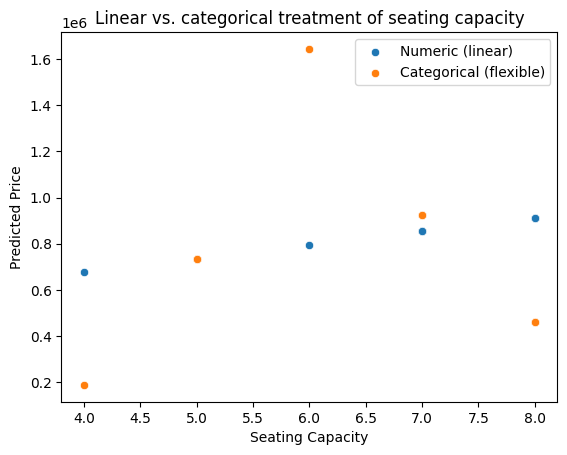

In [10]:
# Overlaying both fits to visually check whether the price-seating relationship
# is actually linear or whether certain seat counts are disproportionately expensive/cheap
sns.scatterplot(x=df['Seating_Capacity'], y=y_hat_cont, label='Numeric (linear)')
sns.scatterplot(x=df['Seating_Capacity'], y=y_hat_cat, label='Categorical (flexible)')
plt.xlabel('Seating Capacity')
plt.ylabel('Predicted Price')
plt.title('Linear vs. categorical treatment of seating capacity')
plt.show()

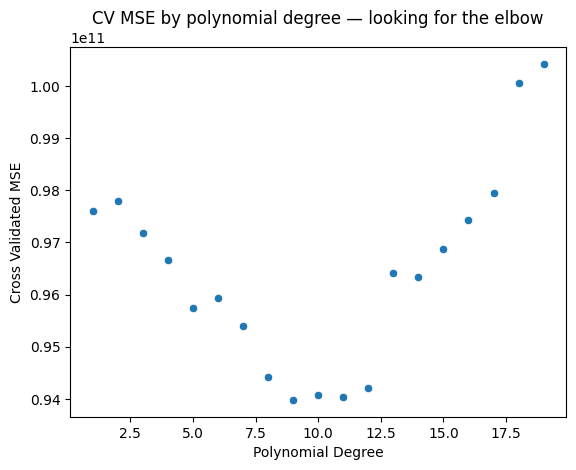

In [11]:
# Create Age from Make_Year — newer cars get age=0, older cars get higher values
df['Age'] = np.max(df['Make_Year']) - df['Make_Year']

y = df['Price']
x = df[['Age']]

d_max = 20
mses = []

for d in range(1, d_max):
    # PolynomialFeatures expands Age into [Age, Age², ..., Age^d]
    # This lets the regression fit a smooth curve rather than a straight line
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xp = poly.fit_transform(x)
    reg = LinearRegression().fit(Xp, y)

    # 10-fold CV to estimate out-of-sample error honestly
    # shuffle=True prevents folds from being accidentally ordered by year
    kfold = KFold(n_splits=10, shuffle=True, random_state=100)

    scores = cross_val_score(
        reg, Xp, y,
        cv=kfold,
        scoring='neg_mean_squared_error'
        )
    mse = -scores  # negate because sklearn returns negative MSE by convention
    mses.append(mse.mean())

# I'm looking for the elbow — the degree where CV error stops improving and may start
# climbing again as the model overfits to noise in the training data
sns.scatterplot(x=np.arange(1, d_max), y=mses)
plt.ylabel('Cross Validated MSE')
plt.xlabel('Polynomial Degree')
plt.title('CV MSE by polynomial degree — looking for the elbow')
plt.show()

Optimal polynomial degree: 9


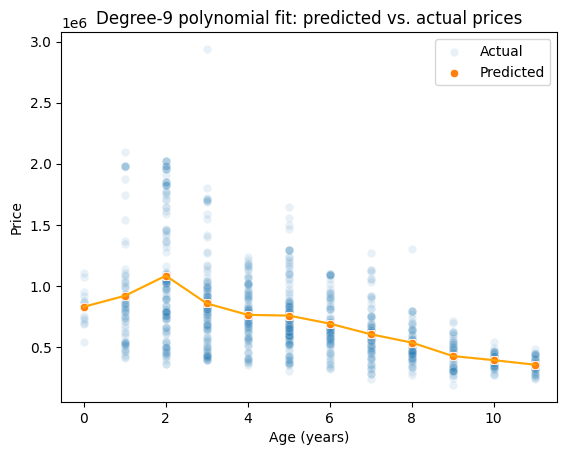

In [12]:
# Pick the degree that minimised CV error
index_star = np.argmin(mses)
d_star = (np.arange(1, d_max))[index_star]
print(f'Optimal polynomial degree: {d_star}')

# Refit on the full dataset using the winning degree
poly = PolynomialFeatures(degree=d_star, include_bias=False)
Xp = poly.fit_transform(x)
reg = LinearRegression().fit(Xp, y)
y_hat = reg.predict(Xp)

# Plot actual prices faintly in the background and overlay the model's predictions
# If the model is capturing the real pattern, the predicted values should run through
# the centre of the actual cloud at each age level
sns.scatterplot(x=np.squeeze(x), y=np.squeeze(y), alpha=.1, label='Actual')
sns.scatterplot(x=np.squeeze(x), y=np.squeeze(y_hat), label='Predicted')
sns.lineplot(x=np.squeeze(x), y=np.squeeze(y_hat), color='orange')
plt.xlabel('Age (years)')
plt.ylabel('Price')
plt.title(f'Degree-{d_star} polynomial fit: predicted vs. actual prices')
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


### Solution Q4


In [13]:
# Load the heart transplant dataset
# Dropping any unnamed index columns that can sneak in from CSV exports
df = pd.read_csv('heart_hw.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()
y = df['y']

# Compute the raw survival rate in each group
# The difference (treatment - control) gives the unadjusted Average Treatment Effect (ATE)
# before I control for anything else
surv = df.groupby('transplant')['y'].mean()
control = surv['control']
treat = surv['treatment']
ate = treat - control
print('Control survival rate:', control)
print('Treatment survival rate:', treat)
print('ATE (treatment - control):', ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE (treatment - control): 0.23017902813299232


In [14]:
# Linear Probability Model: y ~ transplant dummy
# With a binary outcome and a single dummy predictor,
# the intercept should equal the control survival rate and the slope should equal the ATE
# — this is a sanity check that OLS is recovering what we computed by hand above
Tr = pd.get_dummies(df['transplant'], drop_first=True)
reg = LinearRegression().fit(Tr, y)
print('\ny ~ transplant')
print('intercept (= control mean):', float(reg.intercept_))
print('slope (= ATE):', float(reg.coef_[0]))


y ~ transplant
intercept (= control mean): 0.11764705882352966
slope (= ATE): 0.23017902813299193



y ~ transplant + age
transplant coef (age-adjusted): 0.2647016865036745
age coef: -0.013607217160218643


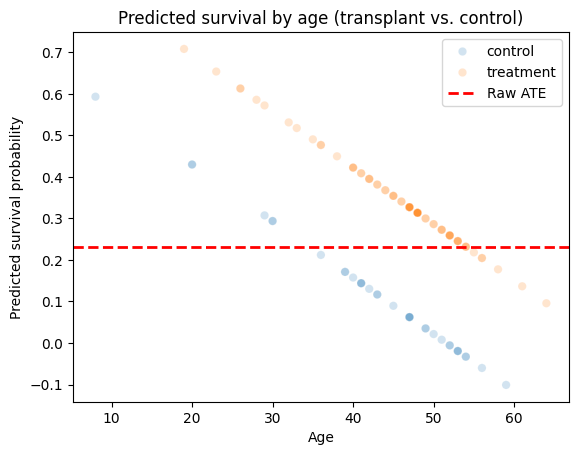

In [15]:
# Add age as a control variable
# The worry: if transplant recipients happen to be younger than controls, the raw ATE
# conflates the transplant effect with an age effect. Controlling for age separates them.
Xta = pd.concat([Tr, df[['age']]], axis=1)
reg = LinearRegression().fit(Xta, y)
print('\ny ~ transplant + age')
print('transplant coef (age-adjusted):', float(reg.coef_[0]))
print('age coef:', float(reg.coef_[1]))

# Store predictions so I can plot survival probability against age for each group
df['y_hat'] = reg.predict(Xta)
ax = sns.scatterplot(x=df['age'],
                y=df['y_hat'],
                hue=df['transplant'],
                alpha=.2)
# Overlay the raw ATE as a dashed reference line
# I want to see for which ages the unadjusted ATE over- or under-estimates the
# actual age-specific transplant benefit
ax.axhline(y=ate, color="red", linestyle="--", linewidth=2, label='Raw ATE')
ax.legend()
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival by age (transplant vs. control)')
plt.show()


y ~ transplant + age + age*transplant
transplant coef: 0.9077513885685884
age coef: -0.0055242575069736795


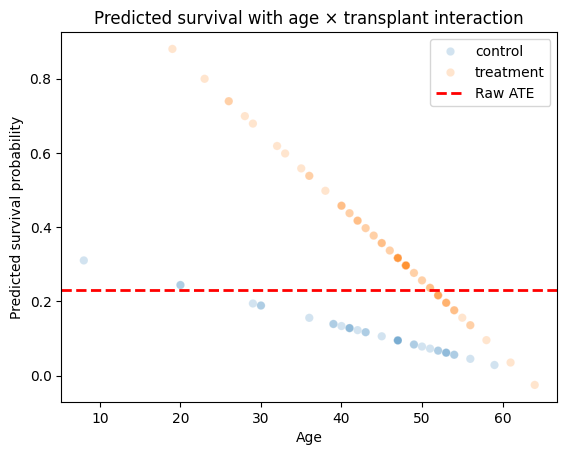

In [16]:
# Add a transplant × age interaction term
# Without the interaction, the model forces the age slope to be identical for both groups
# The interaction lets the transplant benefit vary with age — which is probably more
# realistic, since surgery may help a 40-year-old far more than an 80-year-old
TrxAge = df[['age']].to_numpy() * Tr

X = pd.concat([Tr, 
                 df[['age']],
                 TrxAge], axis=1)
reg = LinearRegression().fit(X, y)
print('\ny ~ transplant + age + age*transplant')
print('transplant coef:', float(reg.coef_[0]))
print('age coef:', float(reg.coef_[1]))

df['y_hat'] = reg.predict(X)
ax = sns.scatterplot(x=df['age'],
                y=df['y_hat'],
                hue=df['transplant'],
                alpha=.2)
ax.axhline(y=ate, color="red", linestyle="--", linewidth=2, label='Raw ATE')
ax.legend()
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival with age × transplant interaction')
plt.show()

**Q4.6 — My concerns about using this model for transplant allocation:**

A few things worry me about deploying something like this in practice:

- The training data reflects historical patterns in who actually received transplants, and those patterns weren't random. If certain groups faced barriers to referral or diagnosis, the model will pick up those biases and potentially entrench them in future allocations.
- Optimising for predicted survival is not the same as making fair or ethical decisions. An older patient with a lower predicted survival rate still has preferences and rights. "Who's most likely to survive?" is a different question from "Who should get priority?" — and confusing the two is dangerous.
- The model is missing a lot of important variables: disease severity, comorbidities, social support networks, proximity to hospitals, insurance status. Making high-stakes decisions with this much missing information is risky.
- A linear probability model can produce predicted probabilities below 0 or above 1, which is logically incoherent. At the extremes, this could produce nonsensical patient rankings.
- Any model used for decisions like these needs to be rigorously audited by demographic subgroup, recalibrated regularly as medical practice evolves, and paired with meaningful human oversight and a clear process for patients to question or appeal decisions.